In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
from scipy.stats import skewnorm
from scipy import special
from scipy.special import gamma,psi
from scipy.spatial.distance import cdist
import os
import random
from sklearn.metrics import DistanceMetric
dist = DistanceMetric.get_metric('euclidean')
import copy
import seaborn as sns
from scipy.stats import chi2, multivariate_normal
import time
import itertools
from scipy.stats import linregress
from datetime import datetime, timedelta
from sklearn.neighbors import NearestNeighbors
from scipy.special import gammaln


In [2]:
def renyi_Leonenko(neigh_num,alphas,data):

    m=data.shape[1]
    V=pow(math.pi,m/2)/math.gamma(m/2+1)  

    max_k = max(neigh_num)+1

    knn = NearestNeighbors(n_neighbors=max_k, algorithm='brute', metric='euclidean')
  

    knn.fit(data)

    distances, indices = knn.kneighbors(data)

    H=list()

    for q in alphas:
        kn=list()
        for k in neigh_num:
            C=pow(np.exp( gammaln(k) - gammaln(k + 1 - q) ),1/(1-q))
            knn=distances[:, k]       
            knn=knn[np.where(knn>0)]
            norm=len(knn)
            I=np.sum(pow(pow(knn,m)*V*(norm-1)*C,1-q))/norm
            kn.append(1/(1-q)*math.log2(I))
        H.append(kn)
    
    return np.array(H)

In [3]:
def RE_analytical(d, alpha, cov):
    RE = np.log2((2*np.pi)**(d/2)* (np.linalg.det(cov))**0.5) + (1/(1-alpha))*np.log2(alpha**(-d/2))
    return RE

In [4]:
kmin=10
kmax=50
k_dif=5

amin=0.03
amax=5
a_dif=0.03


neigh_num=np.arange(kmin,kmax,k_dif)
alphas=np.arange(amin,amax,a_dif) 

In [6]:
primary_colors = [
    '#F44336',
    '#E91E63',  
    '#9C27B0',  
    '#673AB7',
    '#3F51B5', 
    '#2196F3',
    '#03A9F4',
    '#00BCD4',
    '#009688',
    '#4CAF50',
    '#8BC34A',
    '#CDDC39',
    '#FFEB3B',
    '#FFC107',
    '#FF9800',
    '#FF5722',
    '#795548',
    '#9E9E9E',
    '#607D8B'
]

# Dimensions

In [8]:
estimated_re = []

length=10000

neigh_num=[10]

dim_set = [1,2,3,4,5,6,7,8,9,10,15,20,25]
for i in dim_set:

    dim=i
    cov = np.identity(dim)
    mean = [0]*dim

    dat_norm = np.random.multivariate_normal(mean, cov, size=length)

    H=renyi_Leonenko(neigh_num=neigh_num,alphas=alphas,data=dat_norm)

    estimated_re.append(H)


In [9]:
analytical_re_dims = []

length=100000

cov = np.identity(2)
RE_analy_norm = [RE_analytical(d=1,alpha=alpha,cov=cov) for alpha in alphas] 

analytical_re_dims.append(RE_analy_norm)

dim_set = [2,3,4,5,6,7,8,9,10,15,20,25]
for i in dim_set:

    dim=i
    cov = np.identity(dim)

    RE_analy_norm = [RE_analytical(d=dim,alpha=alpha,cov=cov) for alpha in alphas] 

    analytical_re_dims.append(RE_analy_norm)



In [10]:
estimated_means_re_dims = np.mean(np.asarray(estimated_re), axis=2)
estimated_std_re_dims = np.std(np.asarray(estimated_re), axis=2)

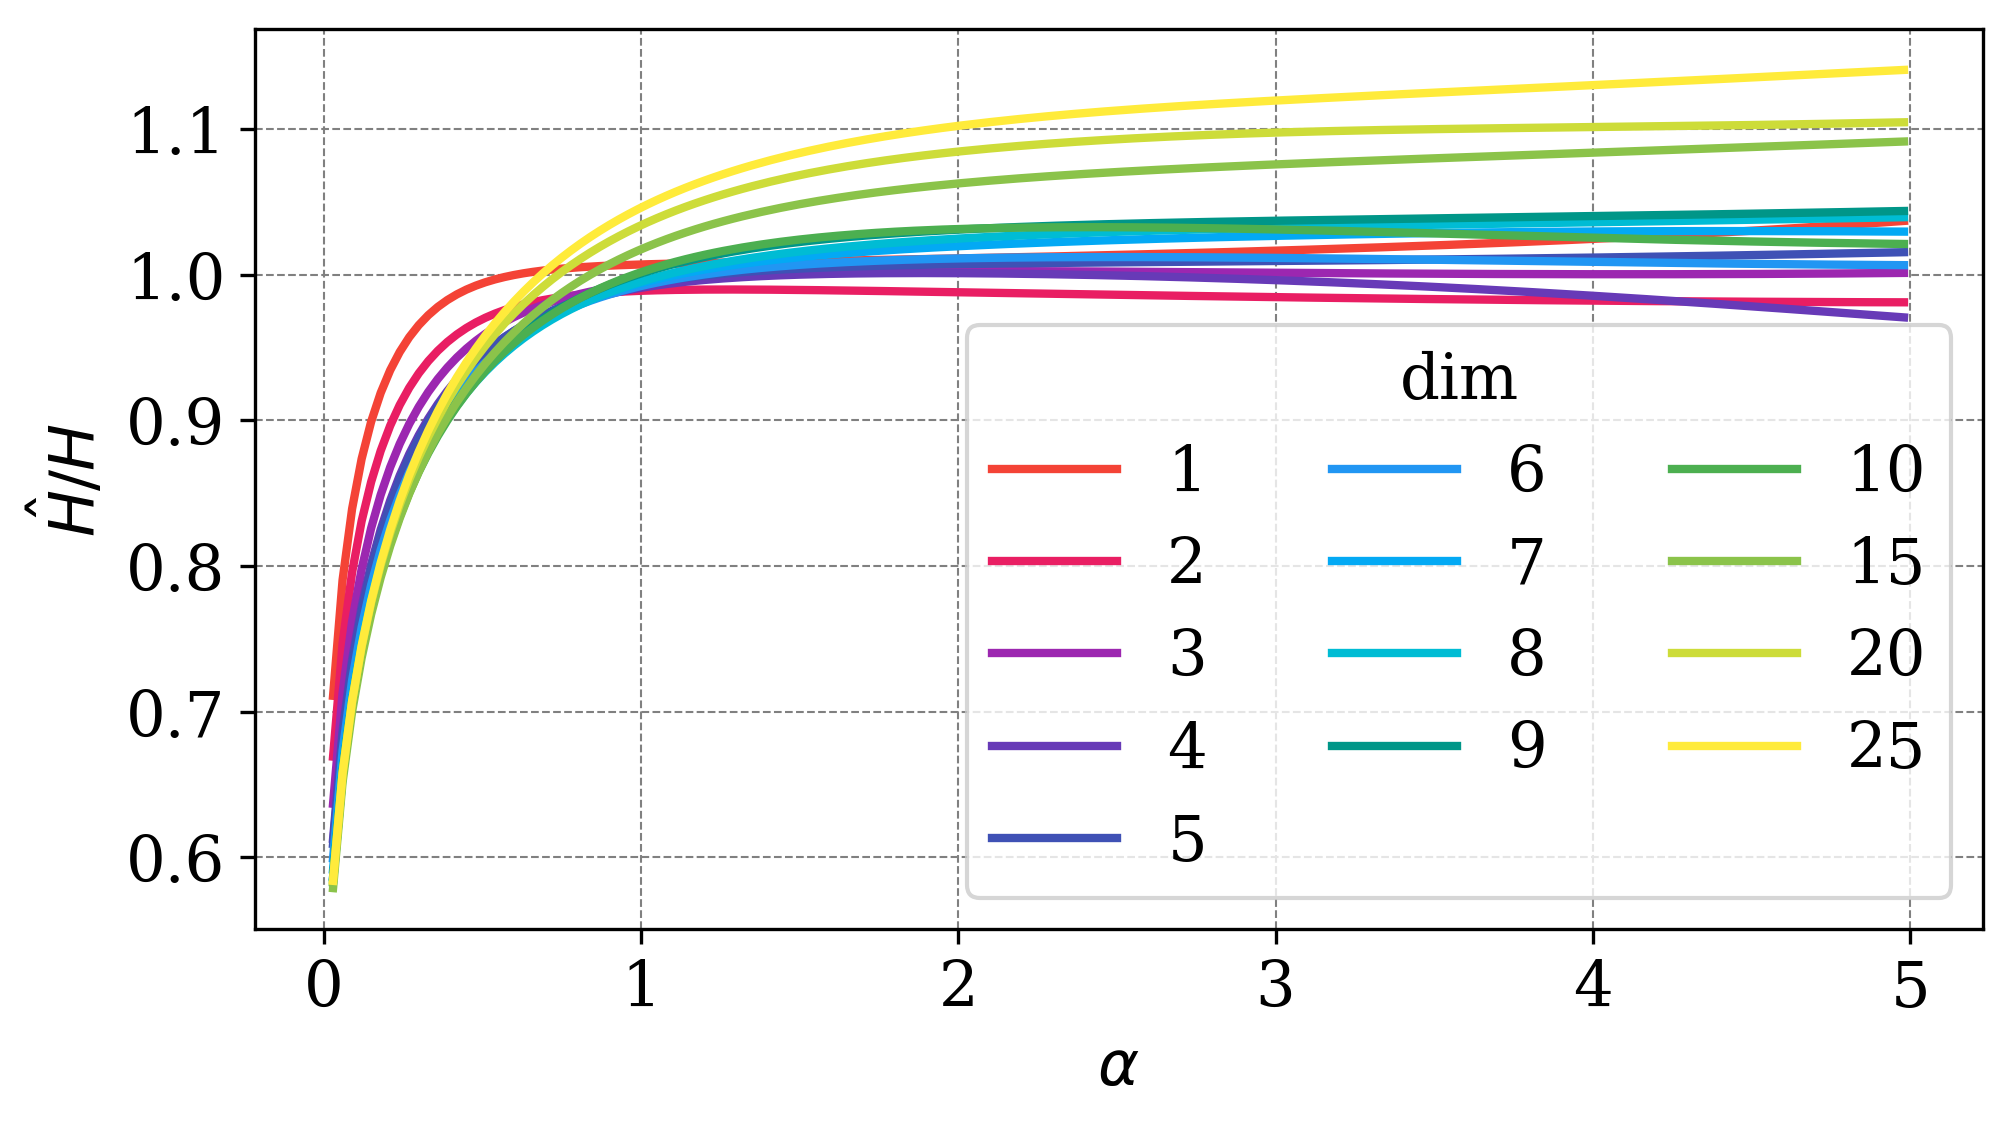

In [12]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

labels_dim=[1,2,3,4,5,6,7,8,9,10,15,20,25]

for i in range(0,len(labels_dim)):
    plt.plot(alphas,np.asarray(estimated_means_re_dims)[i,:]/np.asarray(analytical_re_dims)[i,:],linewidth=2, label=labels_dim[i],c=primary_colors[i])

plt.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)


plt.legend(loc='best',title=r'dim', ncol=3)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\hat{H}/H$')




plt.show()

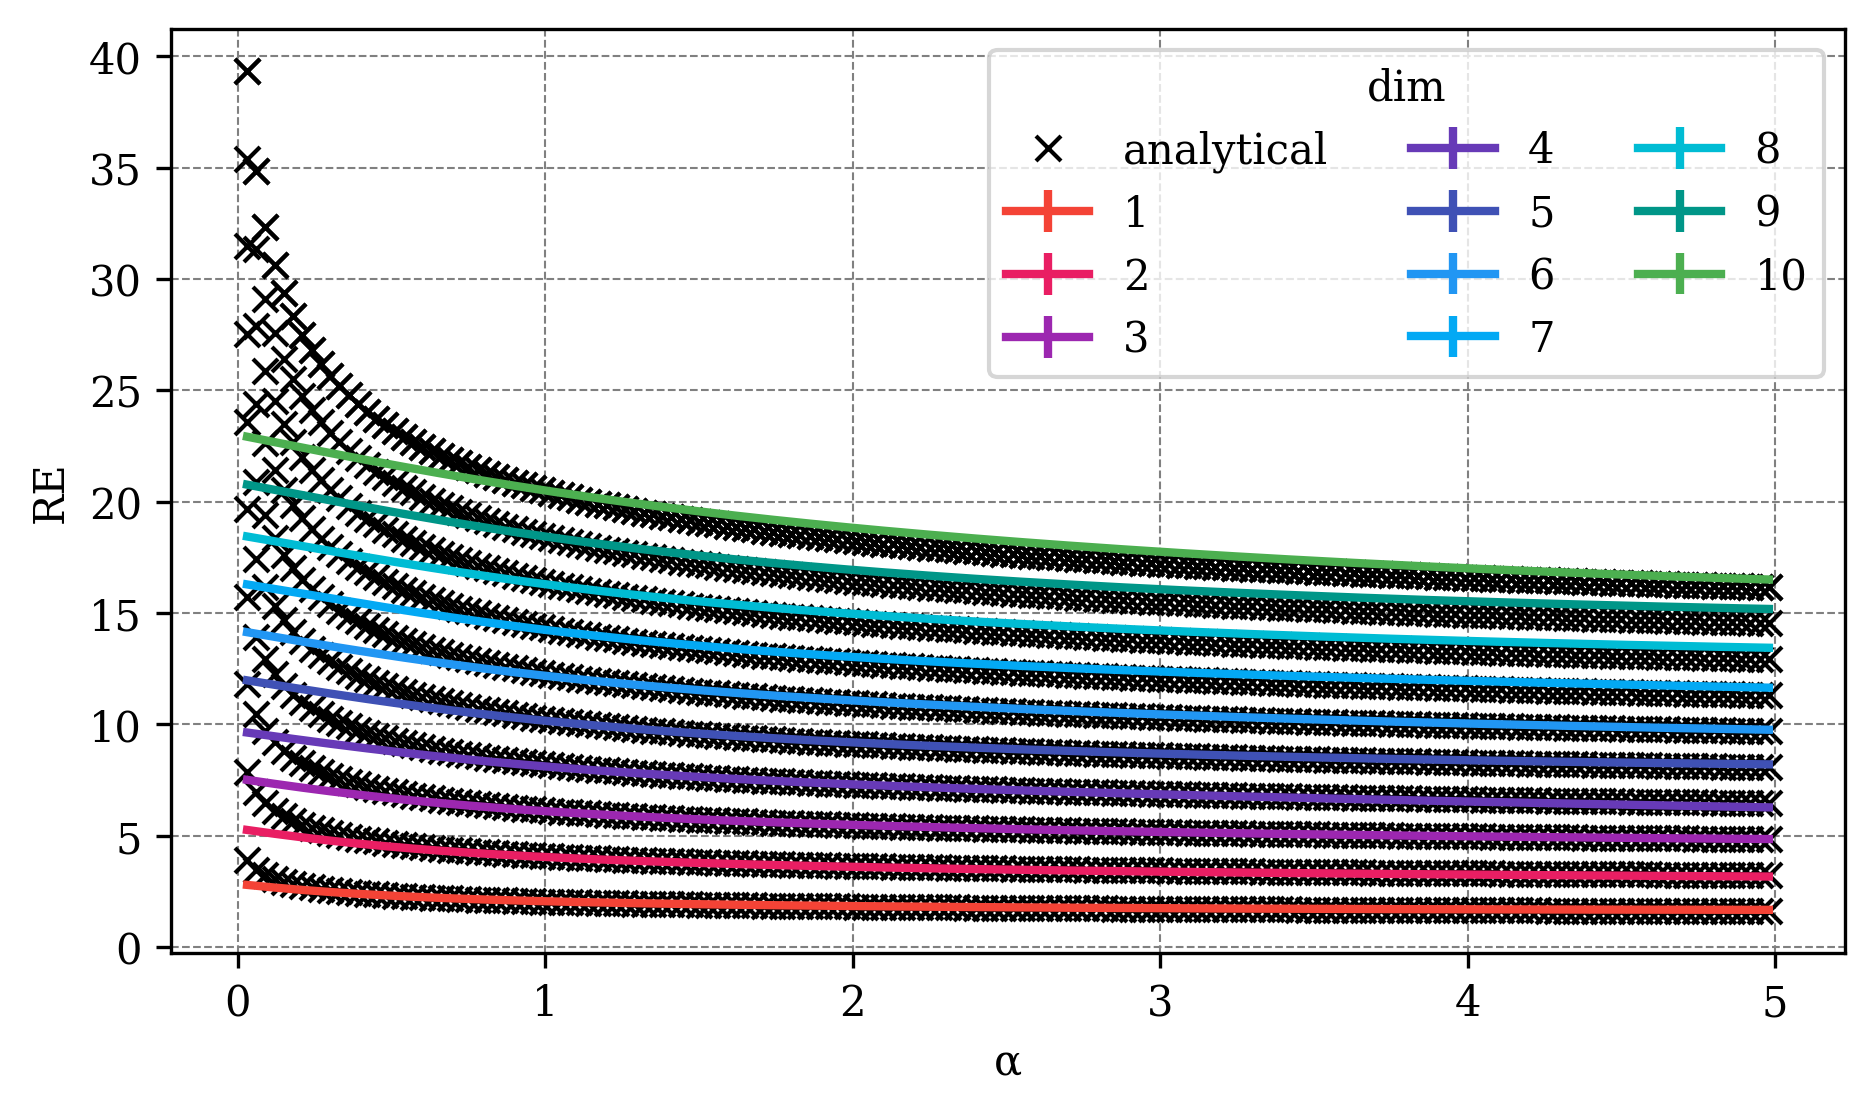

In [13]:
plt.figure(figsize=(7.2, 4.0), dpi=300)
plt.rcParams.update({'font.size': 10})


labels_dim=[1,2,3,4,5,6,7,8,9,10,15,20,25]

for i in range(0,10):
    plt.errorbar(alphas,np.asarray(estimated_means_re_dims)[i,:],np.asarray(estimated_std_re_dims)[i,:], linewidth=2, label=labels_dim[i],c=primary_colors[i])

plt.plot(alphas,np.asarray(analytical_re_dims)[i,:],'x',c='k',label='analytical')
for i in range(0,10):
    plt.plot(alphas,np.asarray(analytical_re_dims)[i,:],'x',c='k')


plt.grid(axis='x', linestyle='--', color='gray', linewidth=0.5)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5)



plt.legend(loc='best',title='dim', ncol=3)
plt.xlabel('\u03B1')
plt.ylabel('RE')



plt.show()

# Neighbours

In [14]:
estimated_re_neigh = []

length=10000

neigh_num=[1,2,3,4,5,10,50,100,1000]

dim=3
cov = np.identity(dim)
mean = [0]*dim

dat_norm = np.random.multivariate_normal(mean, cov, size=length)


for i in neigh_num:

    H=renyi_Leonenko(neigh_num=[i],alphas=alphas,data=dat_norm)

    estimated_re_neigh.append(H)


In [15]:
RE_analy_norm3 = [RE_analytical(d=dim,alpha=alpha,cov=cov) for alpha in alphas] 

In [17]:
k_colors=[primary_colors[0], primary_colors[4], primary_colors[17], primary_colors[9], primary_colors[8], primary_colors[12], primary_colors[16], primary_colors[18], primary_colors[13]]

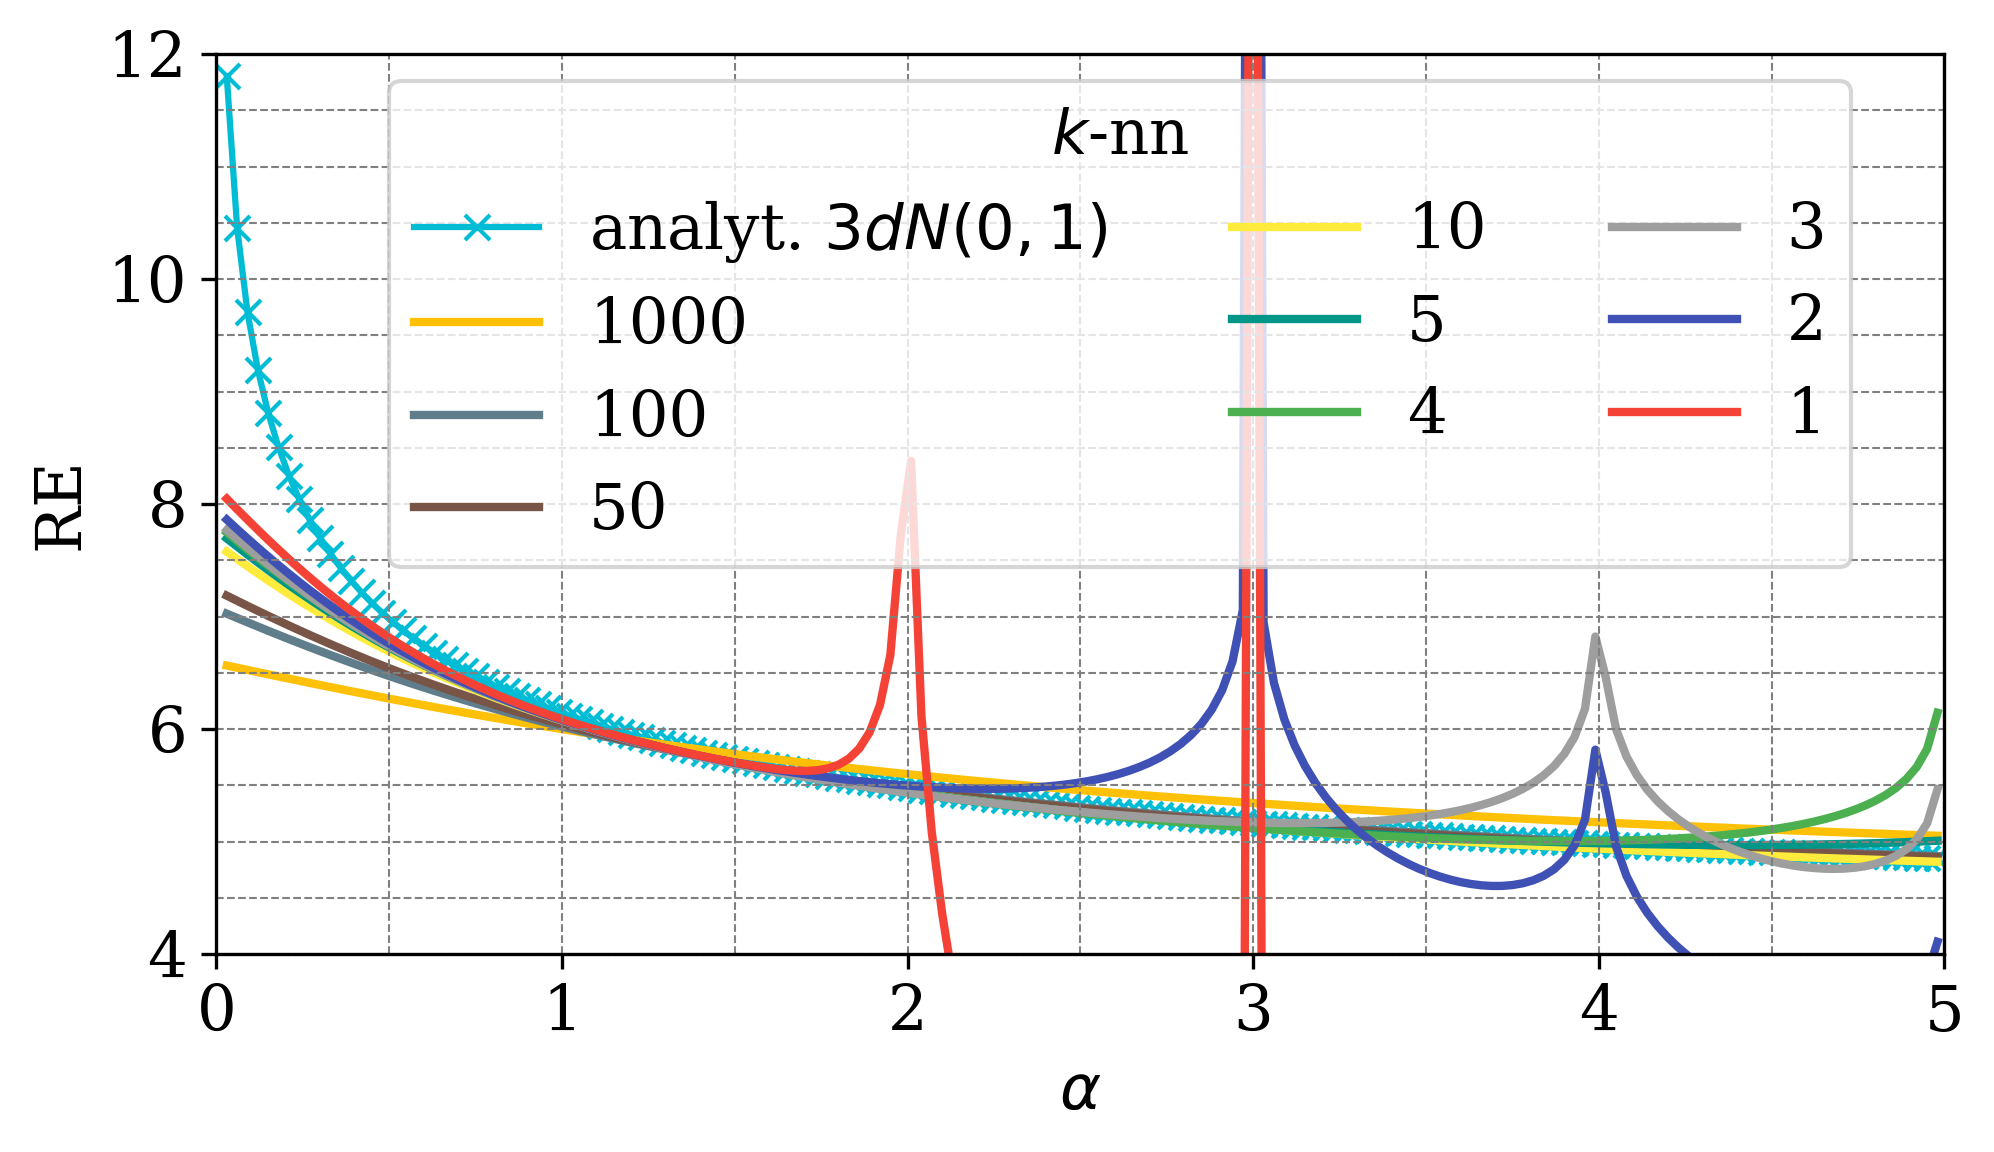

In [18]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif', 
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

legend_n=[1,2,3,4,5,10,50,100,1000]


plt.plot(alphas,np.asarray(RE_analy_norm3),marker='x', c=primary_colors[7],  label=r'analyt. $3dN(0,1)$')


for i in range(0,len(legend_n)):
    plt.plot( alphas, np.asarray(estimated_re_neigh)[8-i,:,:], linewidth=2, label=legend_n[8-i], c=k_colors[8-i] )


plt.ylim(4, 12)
plt.xlim(0, 5)

grid_ticks=np.arange(0,20,0.5)
for i in range(0,40):

    plt.axhline(y=grid_ticks[i],linestyle='--', color='gray', linewidth=0.5)
    plt.axvline(x=grid_ticks[i], linestyle='--', color='gray', linewidth=0.5)


plt.legend(loc=(0.1,0.43),title=r'$k$-nn',ncol=3)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')




plt.show()


# Size

In [ ]:
estimated_re_s = []

length=[100,1000,2000,5000,7000,10000,100000,1000000]


dim=3
cov = np.identity(dim)
mean = [0]*dim


for i in length:

    dat_norm = np.random.multivariate_normal(mean, cov, size=i)

    H=renyi_Leonenko(neigh_num=[10],alphas=alphas,data=dat_norm)

    estimated_re_s.append(H)


RE_analy_norm3 = [RE_analytical(d=dim,alpha=alpha,cov=cov) for alpha in alphas] 

In [ ]:
estimated_means_re_size = np.mean(np.asarray(estimated_re_s), axis=2)
estimated_std_re_size = np.std(np.asarray(estimated_re_s), axis=2)

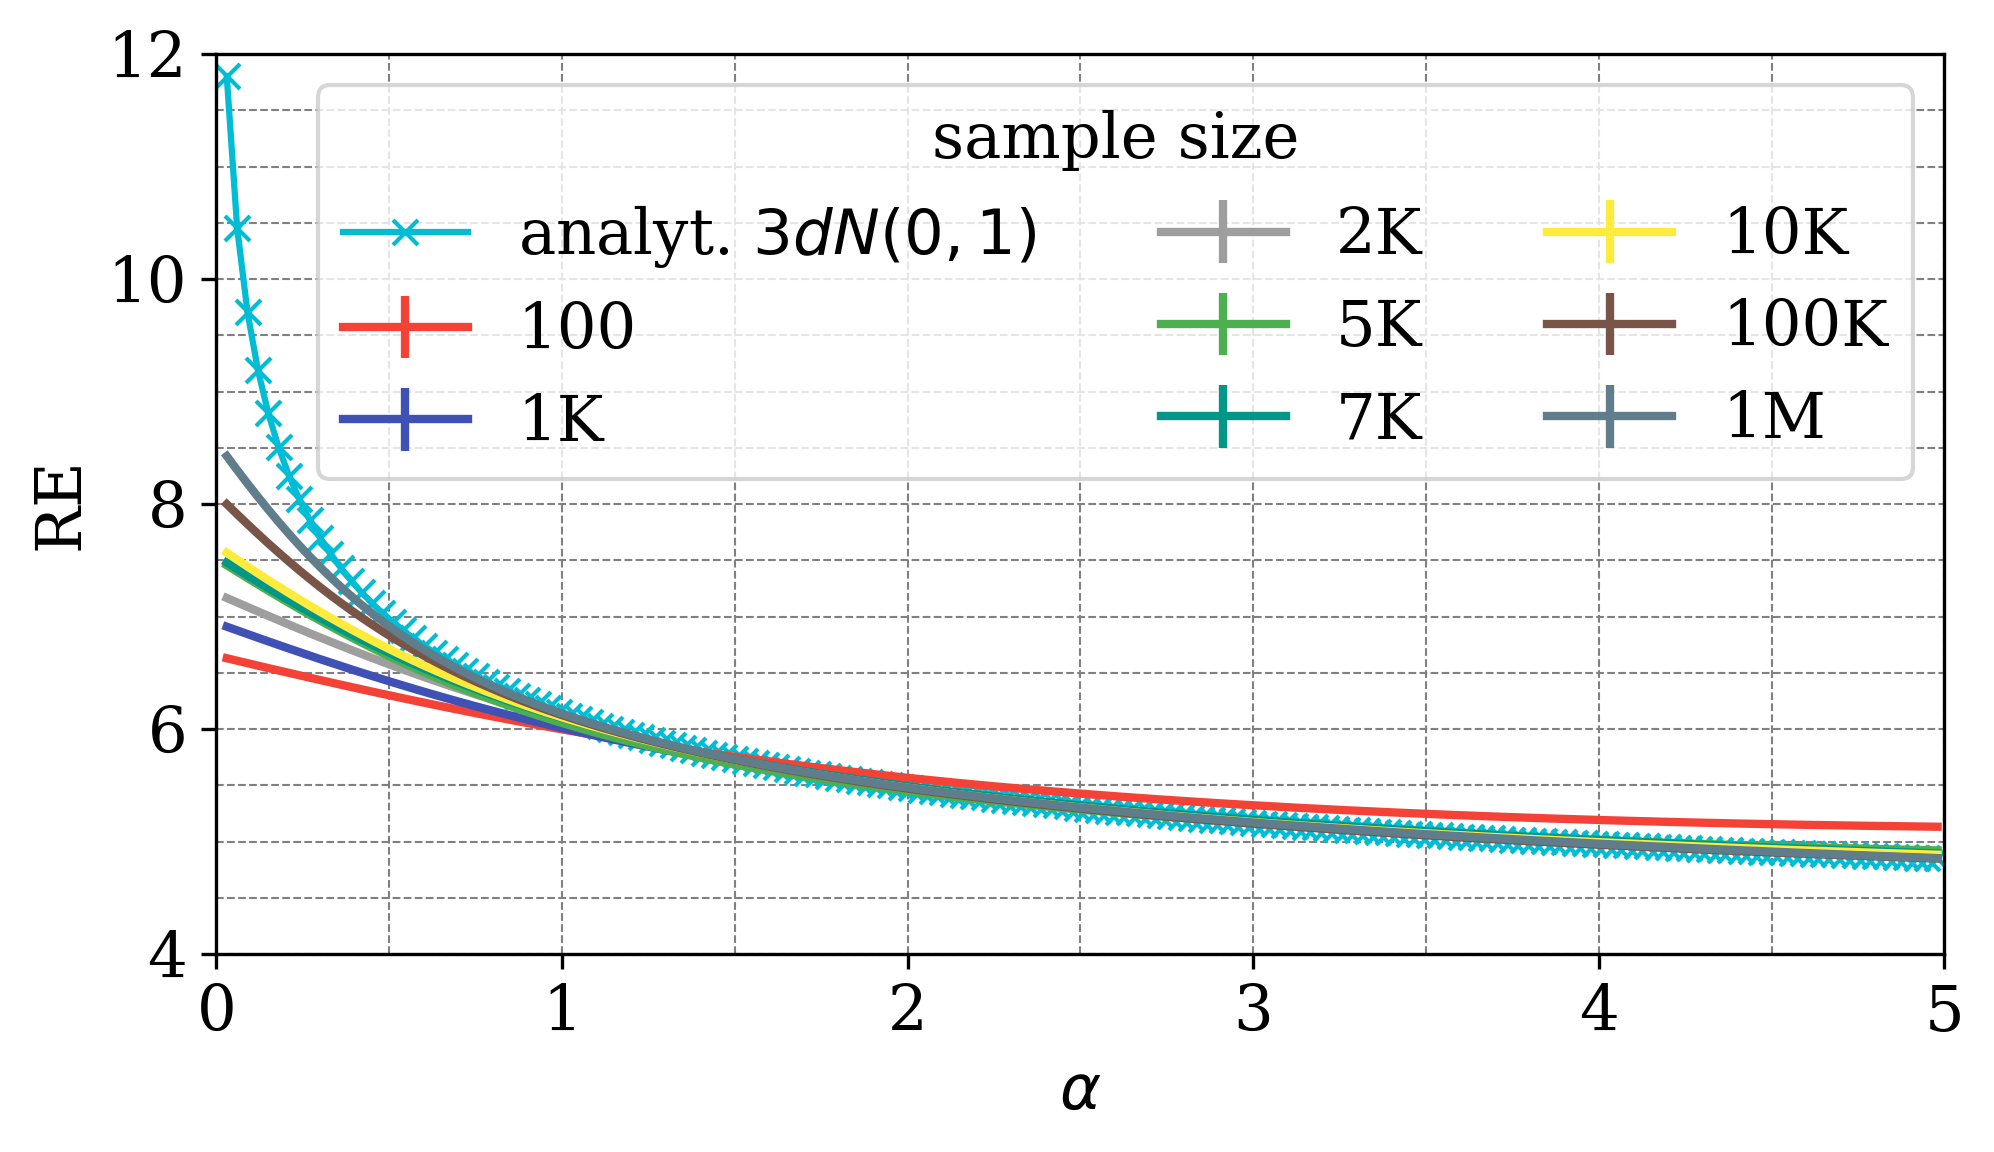

In [62]:

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',  
    'font.size': 15
})

fig = plt.figure(figsize=(7.2, 4.0), dpi=300)


left_margin = 0.15
right_margin = 0.95
bottom_margin = 0.15
top_margin = 0.9

ax = fig.add_axes([
    left_margin,
    bottom_margin,
    right_margin - left_margin,
    top_margin - bottom_margin
])

labels_len=["100","1K","2K","5K","7K","10K","100K","1M"]



for i in range(0,8):
    plt.errorbar(alphas,np.asarray(estimated_means_re_size)[i,:,],np.asarray(estimated_std_re_size)[i,:,], linewidth=2, label=labels_len[i], c=k_colors[i])



plt.ylim(4, 12)
plt.xlim(0, 5)

grid_ticks=np.arange(0,20,0.5)
for i in range(0,40):

    plt.axhline(y=grid_ticks[i],linestyle='--', color='gray', linewidth=0.5)
    plt.axvline(x=grid_ticks[i], linestyle='--', color='gray', linewidth=0.5)


plt.plot(alphas,np.asarray(RE_analy_norm3),marker='x', c=primary_colors[7],  label=r'analyt. $3dN(0,1)$')

plt.legend(loc='best', title="sample size", ncol=3)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'RE')


plt.show()

